# Corrected vs Uncorrected Velocity Comparison

Side-by-side comparison of:
1. **Uncorrected** velocity (no phase-error correction)
2. **GT corrected** velocity (scanner's correction applied)
3. **Model corrected** velocity (`uncorrected + pred_correction × VENC`)

Goal: verify that the model-corrected velocity actually differs from the
uncorrected velocity, and check how it compares to the GT corrected velocity,
before any DICOM intensity mapping muddies the picture.

In [1]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd

from vascular_superenhancement.utils.path_config import load_path_config, _PROJECT_ROOT

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

WORKING_DIR = pc.working_dir
INFERENCE_DIR = WORKING_DIR.parent / "inference"
PATIENT_DATA_DIR = WORKING_DIR / "patient_data"
REPO_ROOT = _PROJECT_ROOT

RUN_NAME = "desiring-ring_epoch-180"
COMPONENTS = ["vx", "vy", "vz"]
TIMEPOINT = 0

splits_df = pd.read_csv(REPO_ROOT / "splits" / "splits_01-15-26.csv")
test_patients = sorted(splits_df.loc[splits_df["split"] == "test", "patient_id"].tolist())
inferred_patients = sorted([d.name for d in (INFERENCE_DIR / RUN_NAME).iterdir() if d.is_dir()])
patients = sorted(set(test_patients) & set(inferred_patients))

print(f"Patients ({len(patients)}): {patients}")
print(f"Timepoint: {TIMEPOINT}")

Found project root at: /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow
Patients (12): ['Balboloop', 'Biswifo', 'Bomatog', 'Boochuto', 'Boumorim', 'Bovutou', 'Cadotueg', 'Detodu', 'Diecudey', 'Diepami', 'Diequipi', 'Dithigog']
Timepoint: 0


In [2]:
def load_sitk_array(path):
    """Load a NIfTI via SimpleITK and return (Z, Y, X) float32 array."""
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path))).astype(np.float32)


def get_paths(pid, comp, t):
    """Return (uncorrected, gt_corrected, model_corrected) paths for one component/timepoint."""
    uncorr = (
        PATIENT_DATA_DIR / pid / "nifti"
        / f"4d_flow_{comp}_{pid}_per_timepoint_corr_fov"
        / f"4d_flow_{comp}_{pid}_frame_{t:02d}.nii.gz"
    )
    gt_corr = (
        PATIENT_DATA_DIR / pid / "nifti"
        / f"4d_flow_{comp}_corr_{pid}_per_timepoint"
        / f"4d_flow_{comp}_corr_{pid}_frame_{t:02d}.nii.gz"
    )
    model_corr = (
        INFERENCE_DIR / RUN_NAME / pid / "predicted_corrected_velocity"
        / f"4d_flow_{comp}_corr"
        / f"4d_flow_{comp}_corr_{pid}_frame_{t:02d}.nii.gz"
    )
    return uncorr, gt_corr, model_corr

## 1. Quick sanity check: do the files exist and are the shapes consistent?

In [3]:
for pid in patients:
    for comp in COMPONENTS:
        uncorr_p, gt_p, model_p = get_paths(pid, comp, TIMEPOINT)
        status = []
        for label, p in [("uncorr", uncorr_p), ("gt_corr", gt_p), ("model", model_p)]:
            status.append(f"{label}={'OK' if p.exists() else 'MISSING'}")
        print(f"{pid:12s} {comp}: {', '.join(status)}")

Balboloop    vx: uncorr=OK, gt_corr=OK, model=OK
Balboloop    vy: uncorr=OK, gt_corr=OK, model=OK
Balboloop    vz: uncorr=OK, gt_corr=OK, model=OK
Biswifo      vx: uncorr=OK, gt_corr=OK, model=OK
Biswifo      vy: uncorr=OK, gt_corr=OK, model=OK
Biswifo      vz: uncorr=OK, gt_corr=OK, model=OK
Bomatog      vx: uncorr=OK, gt_corr=OK, model=OK
Bomatog      vy: uncorr=OK, gt_corr=OK, model=OK
Bomatog      vz: uncorr=OK, gt_corr=OK, model=OK
Boochuto     vx: uncorr=OK, gt_corr=OK, model=OK
Boochuto     vy: uncorr=OK, gt_corr=OK, model=OK
Boochuto     vz: uncorr=OK, gt_corr=OK, model=OK
Boumorim     vx: uncorr=OK, gt_corr=OK, model=OK
Boumorim     vy: uncorr=OK, gt_corr=OK, model=OK
Boumorim     vz: uncorr=OK, gt_corr=OK, model=OK
Bovutou      vx: uncorr=OK, gt_corr=OK, model=OK
Bovutou      vy: uncorr=OK, gt_corr=OK, model=OK
Bovutou      vz: uncorr=OK, gt_corr=OK, model=OK
Cadotueg     vx: uncorr=OK, gt_corr=OK, model=OK
Cadotueg     vy: uncorr=OK, gt_corr=OK, model=OK
Cadotueg     vz: unc

## 2. Value-range table: uncorrected vs GT corrected vs model corrected

In [4]:
from tqdm import tqdm

records = []

for pid in tqdm(patients):
    for comp in COMPONENTS:
        uncorr_p, gt_p, model_p = get_paths(pid, comp, TIMEPOINT)
        if not all(p.exists() for p in [uncorr_p, gt_p, model_p]):
            continue

        uncorr = load_sitk_array(uncorr_p)
        gt_corr = load_sitk_array(gt_p)
        model_corr = load_sitk_array(model_p)

        gt_diff = gt_corr - uncorr
        model_diff = model_corr - uncorr

        records.append({
            "patient": pid,
            "component": comp,
            "uncorr_min": uncorr.min(), "uncorr_max": uncorr.max(),
            "uncorr_mean": uncorr.mean(), "uncorr_std": uncorr.std(),
            "gt_corr_min": gt_corr.min(), "gt_corr_max": gt_corr.max(),
            "gt_corr_mean": gt_corr.mean(), "gt_corr_std": gt_corr.std(),
            "model_corr_min": model_corr.min(), "model_corr_max": model_corr.max(),
            "model_corr_mean": model_corr.mean(), "model_corr_std": model_corr.std(),
            "gt_correction_absmax": np.abs(gt_diff).max(),
            "model_correction_absmax": np.abs(model_diff).max(),
            "gt_correction_std": gt_diff.std(),
            "model_correction_std": model_diff.std(),
            "correction_ratio_std": model_diff.std() / gt_diff.std()
                if gt_diff.std() > 1e-12 else np.nan,
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} triplets")
df[["patient", "component",
    "uncorr_std", "gt_corr_std", "model_corr_std",
    "gt_correction_absmax", "model_correction_absmax",
    "correction_ratio_std"]]

100%|██████████| 12/12 [03:33<00:00, 17.82s/it]

Loaded 36 triplets


,patient,component,uncorr_std,gt_corr_std,model_corr_std,gt_correction_absmax,model_correction_absmax,correction_ratio_std
0,Balboloop,vx,523.219177,526.788025,522.111938,7118.0,260.178345,0.226270
1,Balboloop,vy,526.337097,531.532043,525.795166,7073.0,189.212723,0.114455
2,Balboloop,vz,514.550781,518.432007,513.372437,7097.0,271.045685,0.214206
3,Biswifo,vx,254.820236,248.731583,249.666748,5155.0,324.030853,0.639022
4,Biswifo,vy,234.349243,228.601669,230.216522,5144.0,299.856110,0.628507
5,Biswifo,vz,223.642975,219.447357,220.192429,5166.0,241.685379,0.679329
6,Bomatog,vx,302.585510,294.859314,297.339966,330.0,262.330750,1.023199
7,Bomatog,vy,212.714722,207.234833,208.952133,250.0,237.709854,1.087017
8,Bomatog,vz,202.172745,195.766846,199.117340,234.0,281.458374,1.173942
9,Boochuto,vx,308.181091,301.490295,302.358856,278.0,180.843796,0.788636


## 3. Mid-slice grid: uncorrected | GT corrected | model corrected | GT correction | model correction

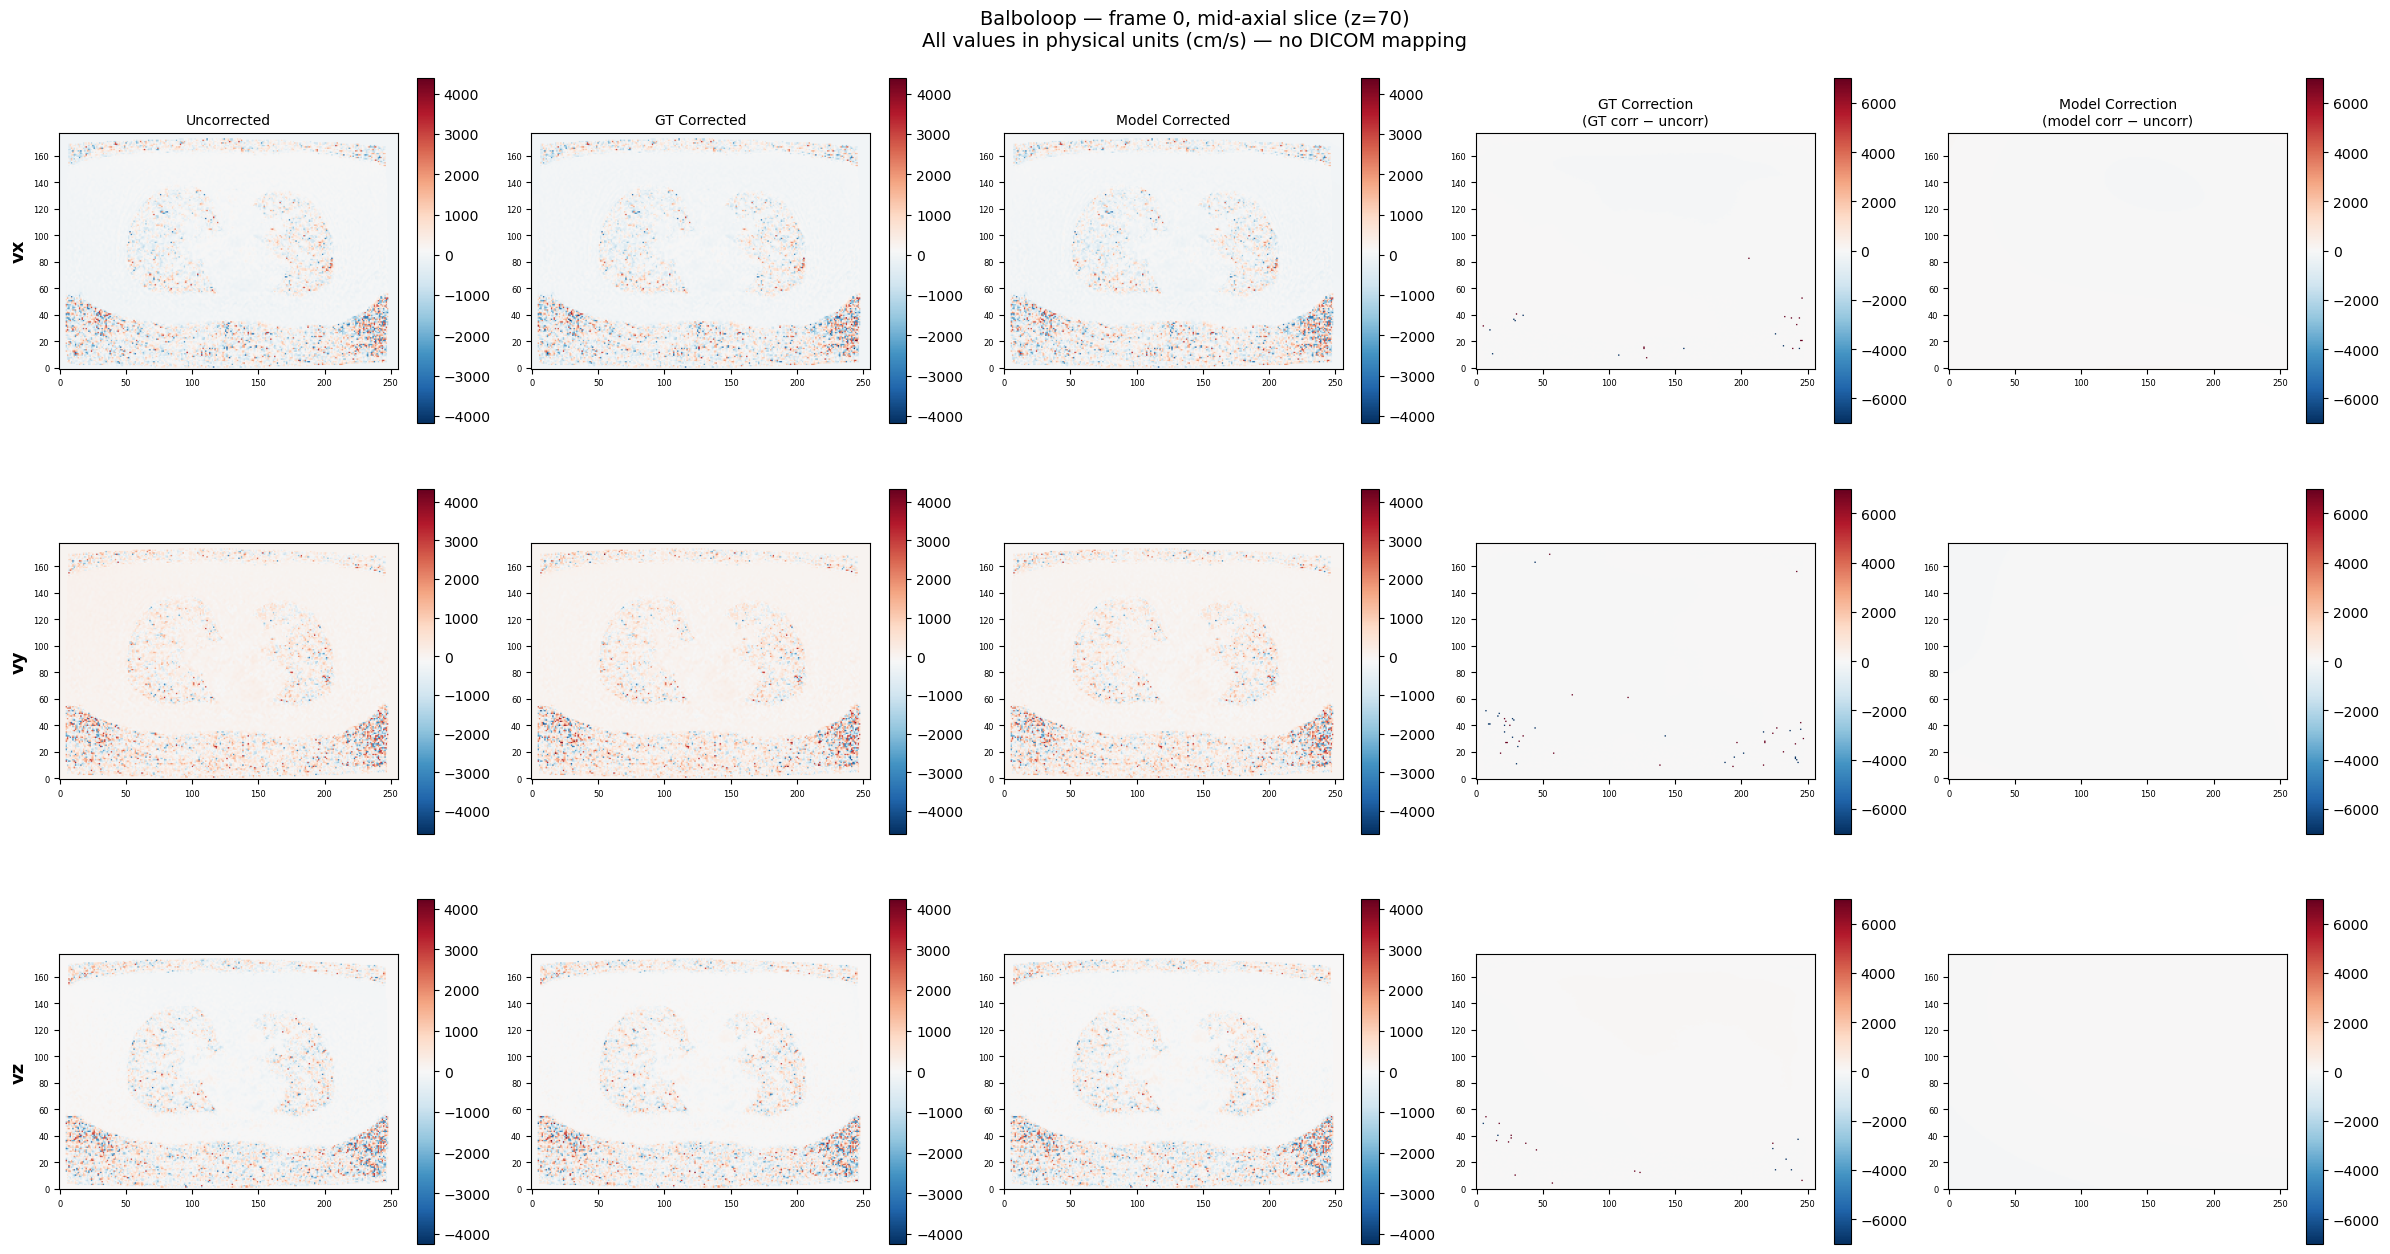

In [5]:
SAMPLE_PID = patients[0]

fig, axes = plt.subplots(3, 5, figsize=(24, 13))
col_titles = ["Uncorrected", "GT Corrected", "Model Corrected",
              "GT Correction\n(GT corr − uncorr)",
              "Model Correction\n(model corr − uncorr)"]

for row, comp in enumerate(COMPONENTS):
    uncorr_p, gt_p, model_p = get_paths(SAMPLE_PID, comp, TIMEPOINT)
    if not all(p.exists() for p in [uncorr_p, gt_p, model_p]):
        for c in range(5):
            axes[row, c].set_title(f"{comp} — MISSING")
        continue

    uncorr = load_sitk_array(uncorr_p)
    gt_corr = load_sitk_array(gt_p)
    model_corr = load_sitk_array(model_p)

    gt_diff = gt_corr - uncorr
    model_diff = model_corr - uncorr

    mid_z = uncorr.shape[0] // 2

    # Velocity columns share the same color range
    vel_vmin = min(uncorr[mid_z].min(), gt_corr[mid_z].min(), model_corr[mid_z].min())
    vel_vmax = max(uncorr[mid_z].max(), gt_corr[mid_z].max(), model_corr[mid_z].max())

    # Correction columns share the same symmetric range
    corr_abs = max(np.abs(gt_diff[mid_z]).max(), np.abs(model_diff[mid_z]).max(), 1e-12)

    slices = [
        (uncorr[mid_z], "RdBu_r", vel_vmin, vel_vmax),
        (gt_corr[mid_z], "RdBu_r", vel_vmin, vel_vmax),
        (model_corr[mid_z], "RdBu_r", vel_vmin, vel_vmax),
        (gt_diff[mid_z], "RdBu_r", -corr_abs, corr_abs),
        (model_diff[mid_z], "RdBu_r", -corr_abs, corr_abs),
    ]

    for col, (data, cmap, vmin, vmax) in enumerate(slices):
        ax = axes[row, col]
        im = ax.imshow(data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046)
        if col == 0:
            ax.set_ylabel(comp, fontsize=13, fontweight="bold")
        if row == 0:
            ax.set_title(col_titles[col], fontsize=10)
        ax.tick_params(labelsize=6)

fig.suptitle(
    f"{SAMPLE_PID} — frame {TIMEPOINT}, mid-axial slice (z={mid_z})\n"
    f"All values in physical units (cm/s) — no DICOM mapping",
    fontsize=14,
)
fig.tight_layout()
plt.show()

## 4. Histogram: correction magnitude (GT vs model)

In [ ]:
fig, axes = plt.subplots(len(patients), 3, figsize=(16, 4 * len(patients)),
                         squeeze=False)

for row, pid in enumerate(patients):
    for col, comp in enumerate(COMPONENTS):
        ax = axes[row, col]
        uncorr_p, gt_p, model_p = get_paths(pid, comp, TIMEPOINT)
        if not all(p.exists() for p in [uncorr_p, gt_p, model_p]):
            ax.set_title(f"{pid} {comp} — MISSING")
            continue

        uncorr = load_sitk_array(uncorr_p)
        gt_corr = load_sitk_array(gt_p)
        model_corr = load_sitk_array(model_p)

        gt_diff = (gt_corr - uncorr).ravel()
        model_diff = (model_corr - uncorr).ravel()

        all_vals = np.concatenate([gt_diff, model_diff])
        bins = np.linspace(np.percentile(all_vals, 0.5),
                           np.percentile(all_vals, 99.5), 120)

        ax.hist(gt_diff, bins=bins, alpha=0.5, label="GT correction", density=True)
        ax.hist(model_diff, bins=bins, alpha=0.5, label="Model correction", density=True)
        ax.axvline(0, color="k", lw=0.5)
        ax.set_title(f"{pid} {comp}", fontsize=9)
        ax.legend(fontsize=7)
        ax.set_xlabel("Correction (cm/s)", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle(
    f"Effective correction histograms: (corrected − uncorrected)\n"
    f"frame {TIMEPOINT} — physical units (cm/s)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

## 5. Scatter: model corrected vs GT corrected (voxel-level)

In [ ]:
fig, axes = plt.subplots(len(patients), 3, figsize=(15, 4 * len(patients)),
                         squeeze=False)
rng = np.random.default_rng(42)

for row, pid in enumerate(patients):
    for col, comp in enumerate(COMPONENTS):
        ax = axes[row, col]
        uncorr_p, gt_p, model_p = get_paths(pid, comp, TIMEPOINT)
        if not all(p.exists() for p in [uncorr_p, gt_p, model_p]):
            ax.set_title(f"{pid} {comp} — MISSING")
            continue

        gt_corr = load_sitk_array(gt_p).ravel()
        model_corr = load_sitk_array(model_p).ravel()

        n = len(gt_corr)
        idx = rng.choice(n, min(50_000, n), replace=False)

        ax.scatter(gt_corr[idx], model_corr[idx], s=0.2, alpha=0.1, rasterized=True)

        valid = np.isfinite(gt_corr) & np.isfinite(model_corr)
        if valid.sum() > 10:
            slope, intercept = np.polyfit(gt_corr[valid], model_corr[valid], 1)
            corr = np.corrcoef(gt_corr[valid], model_corr[valid])[0, 1]
            lims = [min(gt_corr[valid].min(), model_corr[valid].min()),
                    max(gt_corr[valid].max(), model_corr[valid].max())]
            ax.plot(lims, lims, "k--", lw=0.8, label="y=x")
            ax.plot(lims, [slope * x + intercept for x in lims],
                    "r-", lw=1, label=f"fit: {slope:.4f}x + {intercept:.2f}")
            ax.legend(fontsize=7, loc="upper left")
            ax.set_title(f"{pid} {comp}  r={corr:.4f}", fontsize=9)

        ax.set_xlabel("GT corrected (cm/s)", fontsize=8)
        ax.set_ylabel("Model corrected (cm/s)", fontsize=8)
        ax.set_aspect("equal", adjustable="datalim")
        ax.tick_params(labelsize=7)

fig.suptitle(
    f"Voxel-level: model corrected vs GT corrected velocity\n"
    f"frame {TIMEPOINT} — physical units (cm/s)",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

## 6. Summary statistics

In [ ]:
print("=" * 70)
print("SUMMARY: Is the model correction actually being applied?")
print("=" * 70)

print("\n--- Correction magnitude: std of (corrected − uncorrected) ---")
for comp in COMPONENTS:
    sub = df[df["component"] == comp]
    print(f"  {comp}: GT correction std = {sub['gt_correction_std'].mean():.4f} cm/s, "
          f"Model correction std = {sub['model_correction_std'].mean():.4f} cm/s, "
          f"ratio = {sub['correction_ratio_std'].mean():.4f}")

print("\n--- Correction magnitude: max |correction| ---")
for comp in COMPONENTS:
    sub = df[df["component"] == comp]
    print(f"  {comp}: GT max |corr| = {sub['gt_correction_absmax'].mean():.2f} cm/s, "
          f"Model max |corr| = {sub['model_correction_absmax'].mean():.2f} cm/s")

print("\n--- Are model-corrected and uncorrected identical? ---")
all_identical = True
for pid in patients:
    for comp in COMPONENTS:
        uncorr_p, _, model_p = get_paths(pid, comp, TIMEPOINT)
        if not uncorr_p.exists() or not model_p.exists():
            continue
        uncorr = load_sitk_array(uncorr_p)
        model_corr = load_sitk_array(model_p)
        if np.allclose(uncorr, model_corr, atol=1e-6):
            print(f"  *** {pid} {comp}: model corrected == uncorrected (NO correction applied!)")
            all_identical = False

if all_identical:
    print("  All model-corrected volumes differ from uncorrected — correction IS being applied.")

print("\n--- Are model-corrected and GT-corrected nearly identical? ---")
for pid in patients:
    for comp in COMPONENTS:
        _, gt_p, model_p = get_paths(pid, comp, TIMEPOINT)
        if not gt_p.exists() or not model_p.exists():
            continue
        gt_corr = load_sitk_array(gt_p)
        model_corr = load_sitk_array(model_p)
        rmse = np.sqrt(np.mean((gt_corr - model_corr) ** 2))
        rel_rmse = rmse / (gt_corr.std() + 1e-12)
        if rel_rmse < 0.01:
            print(f"  {pid} {comp}: RMSE={rmse:.4f}, rel_RMSE={rel_rmse:.4f} — nearly identical")

print("\nDone.")